# Medical Insurance Cost Prediction - Capstone Project
**Team:** Team Catalyst: Turning Data into Decisions
**Objective:** Predict individual healthcare charges using demographic and lifestyle data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



### 1. Data Loading & Initial Inspection
We load `insurance.csv` and check:
- Dataset shape (rows, columns)
- First few rows to see the raw data
- Missing values (none expected) but we still need to check
- Summary statistics for numeric columns

In [2]:
#Loading the data

df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Tech Crush\insurance.csv")

In [3]:
#to get the dataset shape

df.shape

(1338, 7)

In [4]:
#shows the first five (5) rows so we can see what the raw data looks like

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
#shows column names, non-null counts, and data types

print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


# =======================================
# PHASE 1: EXPLORATORY DATA ANALYSIS (EDA)
# =======================================

In [35]:
#Check missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [36]:
#Summary statistics
print("\nSummary statistics:\n", df.describe())


Summary statistics:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


### Target Variable Distribution
The `charges` column is our target. We compare:
- Original distribution (right-skewed)
- Log-transformed distribution (more normal)
This justifies why we log-transform `charges` before modeling.

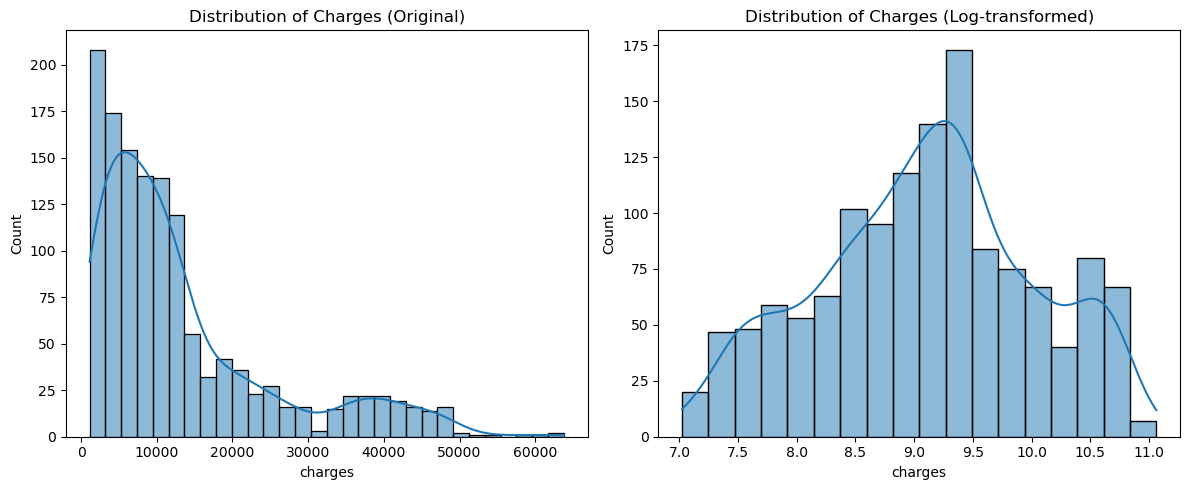

In [37]:
#Distribution of target (charges) – highly right-skewed
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges (Original)')

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['charges']), kde=True)
plt.title('Distribution of Charges (Log-transformed)')
plt.tight_layout()
plt.savefig('charges_distribution.png')
plt.show()

### Smoker Impact on Charges
We group by `smoker` to see average charges. 
A boxplot visualises the massive gap between smokers and non-smokers.


Average charges by smoker status:
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


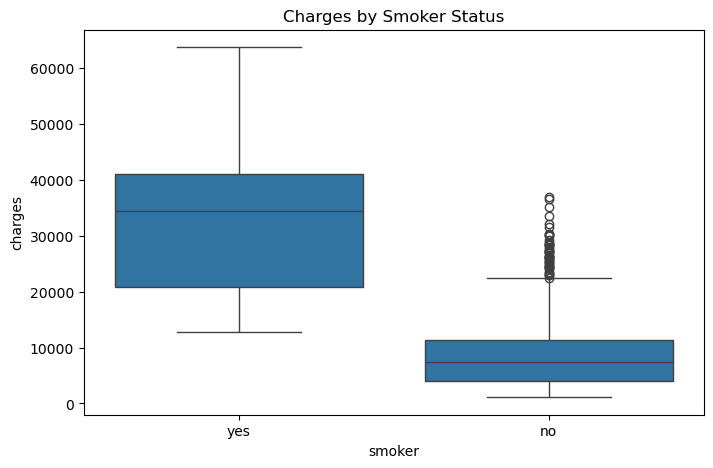

In [38]:
#Smoker impact – the dominant feature
print("\nAverage charges by smoker status:")
print(df.groupby('smoker')['charges'].mean())

plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker Status')
plt.savefig('smoker_boxplot.png')
plt.show()

### Age vs Charges
Colouring points by `smoker` reveals **two distinct upward trends**:
- Non-smokers: gentle increase with age.
- Smokers: steep increase with age (older smokers cost much more).

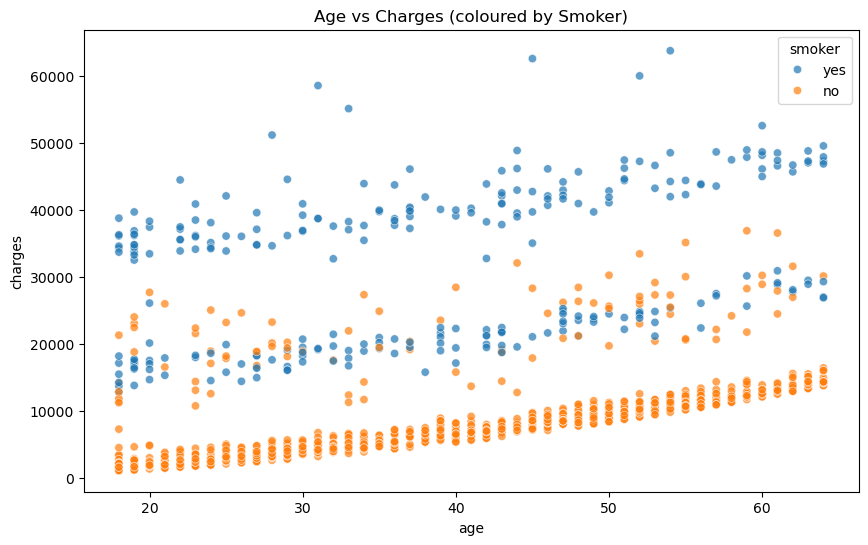

In [39]:
#Age vs Charges coloured by Smoker – shows two distinct trends
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('Age vs Charges (coloured by Smoker)')
plt.savefig('age_smoker_scatter.png')
plt.show()

### BMI (Body Mass Index) vs Charges
High charges cluster at the **top-right** (high BMI + smoker). 
This shows that BMI is only a major risk factor *when combined with smoking*.

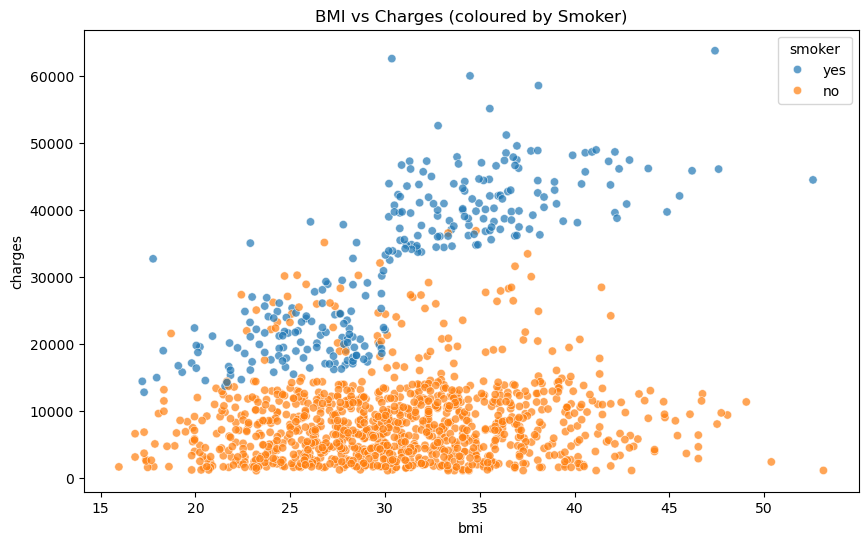

In [40]:
#BMI vs Charges – high BMI + smoker = extreme charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('BMI vs Charges (coloured by Smoker)')
plt.savefig('bmi_smoker_scatter.png')
plt.show()

### Checking Region, Sex, and Children
We quickly check if these features have any noticeable impact:
- Region and Sex: bar plots show very similar average charges.
- Children: slight increase for 1–2 children, but plateaus.

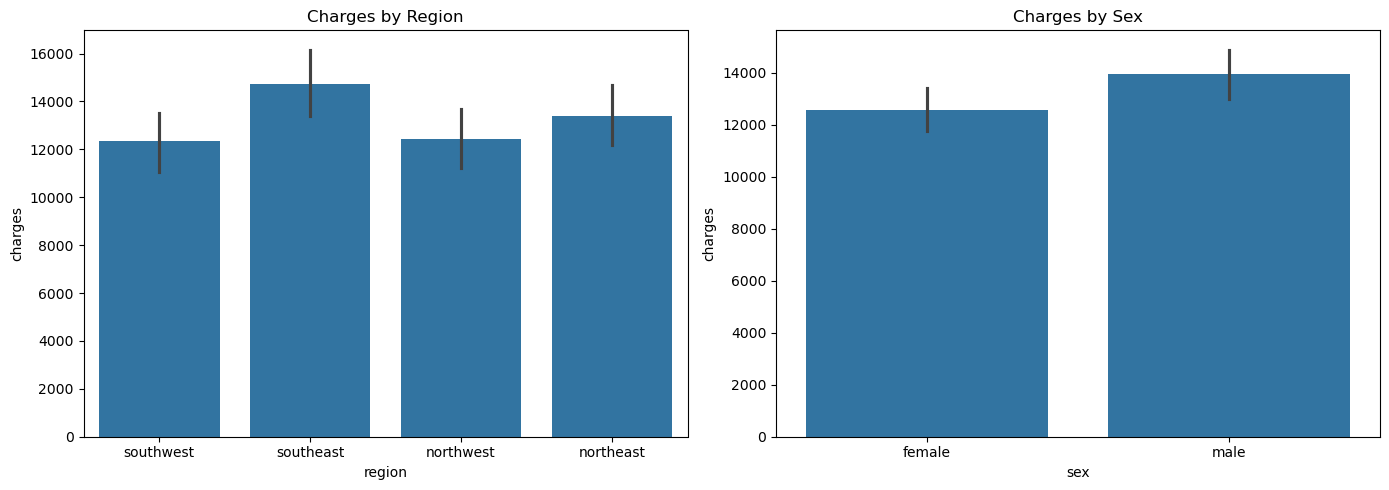

In [41]:
#Region and Sex – negligible impact (quick bar plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='region', y='charges', data=df, ax=axes[0])
axes[0].set_title('Charges by Region')
sns.barplot(x='sex', y='charges', data=df, ax=axes[1])
axes[1].set_title('Charges by Sex')
plt.tight_layout()
plt.savefig('region_sex_impact.png')
plt.show()

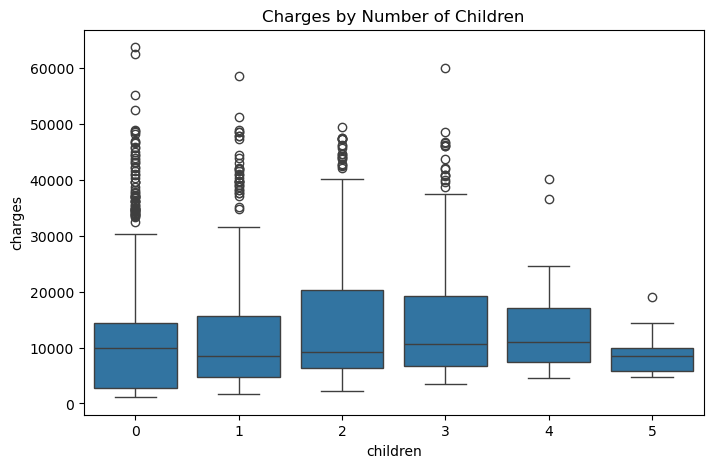

In [42]:
#Children vs Charges
plt.figure(figsize=(8, 5))
sns.boxplot(x='children', y='charges', data=df)
plt.title('Charges by Number of Children')
plt.savefig('children_boxplot.png')
plt.show()

In [ ]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING
# ==========================================

### Feature Engineering
We prepare the data for modeling:
1. **One-Hot Encoding** – convert text categories (sex, smoker, region) to numeric columns.
2. **Interaction Features** – create `bmi_x_smoker` and `age_x_smoker` to capture combined effects.
3. **Log Target** – create `log_charges` to fix skewness.

In [43]:
#One-hot encode categorical variables (drop_first avoids multicollinearity)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print("\nColumns after one-hot encoding:\n", df_encoded.columns.tolist())


Columns after one-hot encoding:
 ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [44]:
#Create interaction features (discovered from EDA)
df_encoded['bmi_x_smoker'] = df_encoded['bmi'] * df_encoded['smoker_yes']
df_encoded['age_x_smoker'] = df_encoded['age'] * df_encoded['smoker_yes']

In [45]:
#Log-transform the target to handle skewness
df_encoded['log_charges'] = np.log(df_encoded['charges'])

# Define features (X) and target (y)
X = df_encoded.drop(['charges', 'log_charges'], axis=1)
y = df_encoded['log_charges']

print("\nFeature names:\n", X.columns.tolist())


Feature names:
 ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_x_smoker', 'age_x_smoker']


# ==========================================
# PHASE 3: BUILD & EVALUATE MODELS
# ==========================================

### Train-Test Split & Scaling
- Split data into 80% training and 20% testing (random_state=42 for reproducibility).
- Scale numeric features (age, bmi, etc.) using `StandardScaler` – essential for Linear Regression.

In [47]:
#Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scale numeric features (for linear models)
numeric_cols = ['age', 'bmi', 'children', 'bmi_x_smoker', 'age_x_smoker']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

### Model Training
We train two models:
- **Linear Regression** – simple, highly interpretable (we can read coefficients).
- **Random Forest** – powerful tree-based model that captures non-linear patterns.

In [31]:
# --- Model A: Linear Regression (Interpretable) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_log_lr = lr.predict(X_test_scaled)

# --- Model B: Random Forest (Non-linear, robust) ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # RF doesn't need scaling
y_pred_log_rf = rf.predict(X_test)

### Model Evaluation
We define a helper function that:
1. Converts log predictions back to dollars using `np.exp()`.
2. Calculates MAE (average dollar error), RMSE, and R².
We then compare both models.

In [48]:
#Evaluation function (convert log predictions back to dollars)
def evaluate_model(y_true_log, y_pred_log, model_name):
    y_true_dollars = np.exp(y_true_log)
    y_pred_dollars = np.exp(y_pred_log)
    mae = mean_absolute_error(y_true_dollars, y_pred_dollars)
    rmse = np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars))
    r2 = r2_score(y_true_dollars, y_pred_dollars)
    print(f"\n{model_name} Performance:")
    print(f"  MAE:  ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    return mae, rmse, r2

print("\n" + "="*50)
evaluate_model(y_test, y_pred_log_lr, "Linear Regression")
evaluate_model(y_test, y_pred_log_rf, "Random Forest")
print("="*50)




Linear Regression Performance:
  MAE:  $2,600.77
  RMSE: $5,378.57
  R²:   0.8137

Random Forest Performance:
  MAE:  $2,083.63
  RMSE: $4,395.29
  R²:   0.8756


# ==========================================
# PHASE 4: INTERPRET RESULTS
# ==========================================

### Feature Interpretation
We extract:
- **Linear Regression coefficients** – show the exact weight (impact) of each feature.
- **Random Forest feature importance** – shows which features are used most in decision trees.
We visualise the top 5 from each.

In [49]:
#Linear Regression Coefficients (for interpretability)
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print("\nTop 5 Most Influential Features (Linear Regression):")
print(coef_df.head(5))

print("\nBottom 5 Least Influential Features (Linear Regression):")
print(coef_df.tail(5))


Top 5 Most Influential Features (Linear Regression):
        Feature  Coefficient
4    smoker_yes     1.201188
8  bmi_x_smoker     0.677561
0           age     0.581641
2      children     0.123341
1           bmi     0.006160

Bottom 5 Least Influential Features (Linear Regression):
            Feature  Coefficient
5  region_northwest    -0.064684
3          sex_male    -0.084409
6  region_southeast    -0.127352
7  region_southwest    -0.151146
9      age_x_smoker    -0.556788


In [50]:
#Random Forest Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Most Important Features (Random Forest):")
print(importance_df.head(5))


Top 5 Most Important Features (Random Forest):
        Feature  Importance
0           age    0.375169
8  bmi_x_smoker    0.345906
1           bmi    0.086745
9  age_x_smoker    0.064297
4    smoker_yes    0.047991


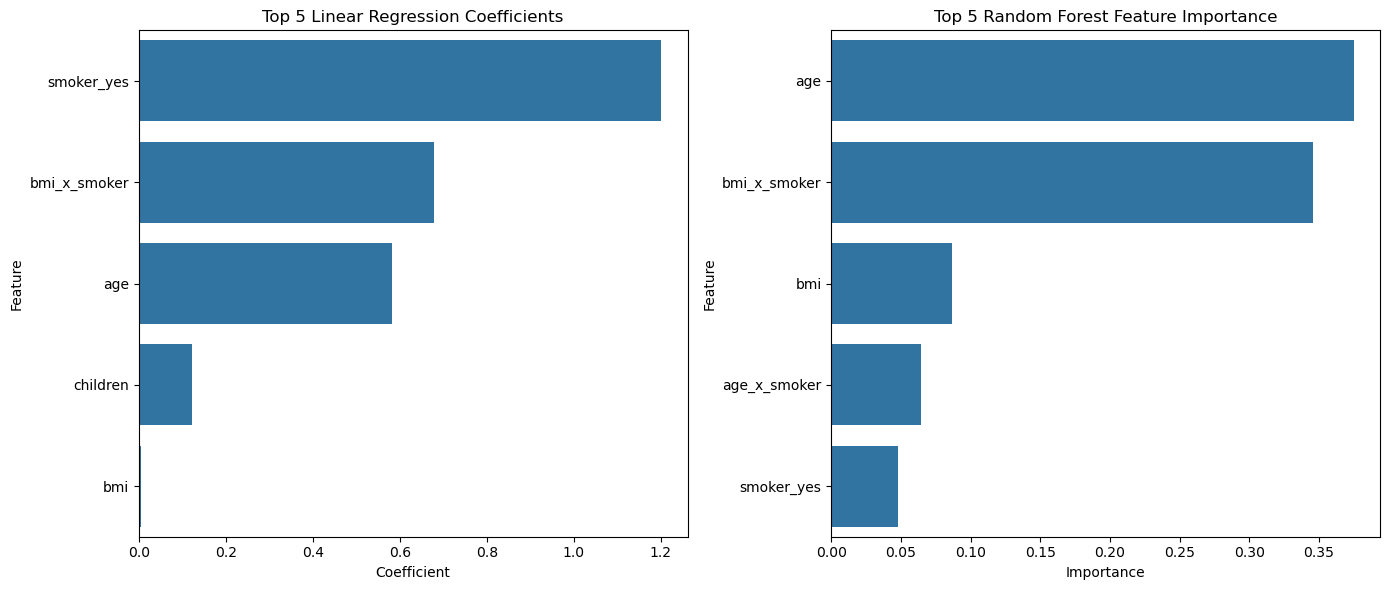

In [51]:
#Visualise coefficients & importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Linear coefs
top_coef = coef_df.head(5)
sns.barplot(x='Coefficient', y='Feature', data=top_coef, ax=axes[0])
axes[0].set_title('Top 5 Linear Regression Coefficients')
# RF importance
top_imp = importance_df.head(5)
sns.barplot(x='Importance', y='Feature', data=top_imp, ax=axes[1])
axes[1].set_title('Top 5 Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

### Business Insights & Recommendations
Based on our model, we summarise:
- Which features matter most.
- Actionable recommendations for the insurance provider.
- We also save the coefficient tables as CSV for later reference.

In [52]:
#Business-friendly summary (print to console)
print("\n" + "="*60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)
print("1. SMOKING is the #1 cost driver – smokers pay ~3x more than non-smokers.")
print("2. AGE matters more for smokers – older smokers see accelerated cost growth.")
print("3. BMI only significantly increases costs for SMOKERS (obese smokers are highest risk).")
print("4. SEX and REGION have negligible impact – can simplify national pricing.")
print("5. CHILDREN has a small positive effect, but plateaus after 2 children.")
print("\nRECOMMENDATIONS:")
print("- Implement tiered pricing: separate smoker/non-smoker premium tables.")
print("- Offer smoking cessation programmes with premium discounts.")
print("- Combine BMI + smoker status for high-risk underwriting checks.")
print("- Drop regional price variation to reduce administrative overhead.")
print("="*60)

# Save the coefficient table to CSV for your report
coef_df.to_csv('coefficients.csv', index=False)
importance_df.to_csv('feature_importance.csv', index=False)


print("\n--- THANK YOU FOR YOUR TIME ---")


BUSINESS INSIGHTS & RECOMMENDATIONS
1. SMOKING is the #1 cost driver – smokers pay ~3x more than non-smokers.
2. AGE matters more for smokers – older smokers see accelerated cost growth.
3. BMI only significantly increases costs for SMOKERS (obese smokers are highest risk).
4. SEX and REGION have negligible impact – can simplify national pricing.
5. CHILDREN has a small positive effect, but plateaus after 2 children.

RECOMMENDATIONS:
- Implement tiered pricing: separate smoker/non-smoker premium tables.
- Offer smoking cessation programmes with premium discounts.
- Combine BMI + smoker status for high-risk underwriting checks.
- Drop regional price variation to reduce administrative overhead.

--- THANK YOU FOR YOUR TIME ---
